# Transits of ringed planets

`squishyplanet` can model transits of planets that host an opaque ring via the `RingedSystem` class. The ring is assumed to be:

- perfectly flat and infinitely thin,
- perfectly circular and concentric with the planet,
- perfectly opaque,
- bounded by an inner radius `ring_inner_r` and an outer radius `ring_outer_r`, both in units of the stellar radius. The inner radius must be larger than the planet's equatorial radius `r`.

By default the ring lies in the planet's equatorial plane: its 3D orientation follows the planet's `obliq` and `prec` angles, including the time-varying orientation of a tidally locked planet (though we likely wouldn't expect such a configuration). You can decouple the ring from the planet by passing `ring_obliq` and `ring_prec` explicitly.

The flux blocked by the combined planet + ring silhouette is computed with the same Green's theorem boundary integrals used for the planet alone, so it inherits support for arbitrary-order polynomial limb darkening laws and is exact up to quadrature/root-finding precision. That includes the awkward configurations where the planet's disk overlaps the projected ring edges, or where a nearly edge-on ring crosses the stellar limb four times: no small-planet or non-overlapping approximations are involved. See the [changelog](https://squishyplanet.readthedocs.io/en/latest/changelog.html) and the `engine.ringed_transit` module documentation for details on the algorithm.

In [11]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

from squishyplanet import OblateSystem, RingedSystem

## Creating a `RingedSystem`

`RingedSystem` is a subclass of `OblateSystem` and accepts all of the same arguments (see the [Quickstart](https://squishyplanet.readthedocs.io/en/latest/quickstart.html)), plus the four ring parameters. Let's set up a Saturn-like planet on a circular orbit. Note that with `t_peri = -period / 4`, a circular orbit with the default `omega` and `Omega` reaches mid-transit at $t=0$.

One thing to point out: the planet below is a sphere, so its own `obliq` and `prec` don't affect its outline at all. But since we don't pass `ring_obliq` or `ring_prec`, the ring lies in the equatorial plane those angles define, and they shape the transit through the ring alone.

In [20]:
state = {
    "times": jnp.linspace(-0.75, 0.75, 500),  # days
    "t_peri": -2.5,
    "period": 10.0,
    "a": 5.0,
    "i": jnp.pi / 2 - 0.01,
    "r": 0.1,
    "obliq": 0.4,
    "prec": jnp.pi / 2,
    "tidally_locked": False,
    "ld_u_coeffs": jnp.array([0.3, 0.1]),
}

ringed = RingedSystem(ring_inner_r=0.15, ring_outer_r=0.3, **state)
planet_only = OblateSystem(**state)

`RingedSystem.illustrate` works just like `OblateSystem.illustrate`, but overlays the projected outlines of both ring edges and (optionally, controlled by `ring_fill`) fills the annulus between them. One caveat noted in its docstring: the layering is cosmetic, so the filled annulus is drawn on top of the planet even though half of the physical ring passes behind it.

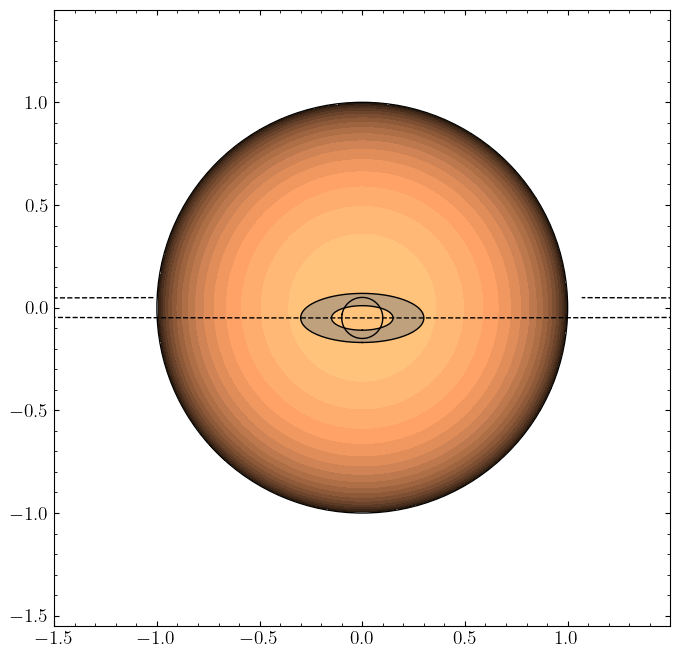

In [21]:
ringed.illustrate(times=jnp.array([0.0]), window_size=3.0)

## The lightcurve

Generating a lightcurve is identical to the `OblateSystem` case:

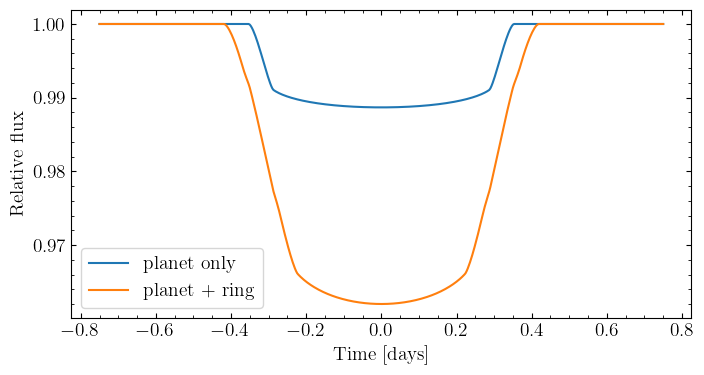

In [22]:
lc_ringed = ringed.lightcurve()
lc_planet = planet_only.lightcurve()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(state["times"], lc_planet, label="planet only")
ax.plot(state["times"], lc_ringed, label="planet + ring")
ax.set(xlabel="Time [days]", ylabel="Relative flux")
ax.legend();

The ring both deepens the transit (it blocks extra area) and lengthens it (the outer ring edge reaches the stellar limb well before the planet does), and it reshapes ingress/egress: the initial shallow slopes are the annulus sliding onto the star, followed by the steeper drop of the planet itself.

## Changing the ring's orientation

To orient the ring independently of the planet, pass *both* `ring_obliq` and `ring_prec` (defined identically to the planet's `obliq` and `prec`; see the [geometry visualizations](https://squishyplanet.readthedocs.io/en/latest/geometry.html)). The projected annulus depends on how the ring plane is tilted relative to the line of sight, and some care is needed: for example, for an exactly edge-on orbit ($i = \pi/2$), a ring with `ring_prec = 0` presents itself perfectly edge-on for *any* value of `ring_obliq` and blocks no light at all.

Like every other model parameter, the ring parameters can be updated at call time by passing a dictionary to `lightcurve` -- this is the same mechanism you would use when fitting data. Here is a family of models where only the ring's obliquity changes:

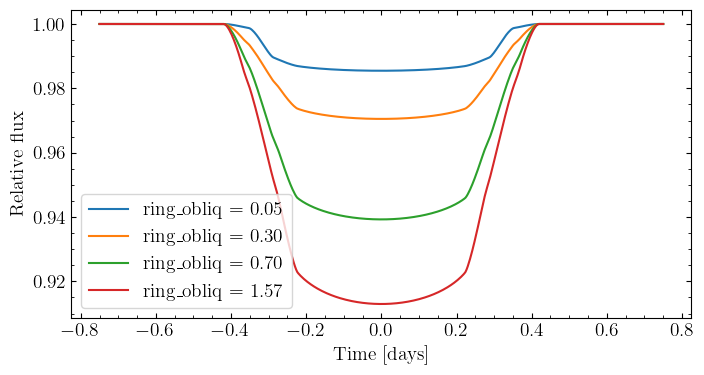

In [23]:
decoupled = RingedSystem(
    ring_inner_r=0.15,
    ring_outer_r=0.3,
    ring_obliq=0.2,
    ring_prec=jnp.pi / 2,
    **state,
)

fig, ax = plt.subplots(figsize=(8, 4))
for ring_obliq in [0.05, 0.3, 0.7, jnp.pi / 2]:
    lc = decoupled.lightcurve({"ring_obliq": jnp.array([ring_obliq])})
    ax.plot(state["times"], lc, label=f"ring_obliq = {ring_obliq:.2f}")
ax.set(xlabel="Time [days]", ylabel="Relative flux")
ax.legend();

We can also visualize these 4 geometries by creating a new `RingedSystem` for each one and calling `illustrate`. Note that we don't need to create new objects to generate lightcurves, but we do just for illustrations since it relies on some internal state created at object initialization.

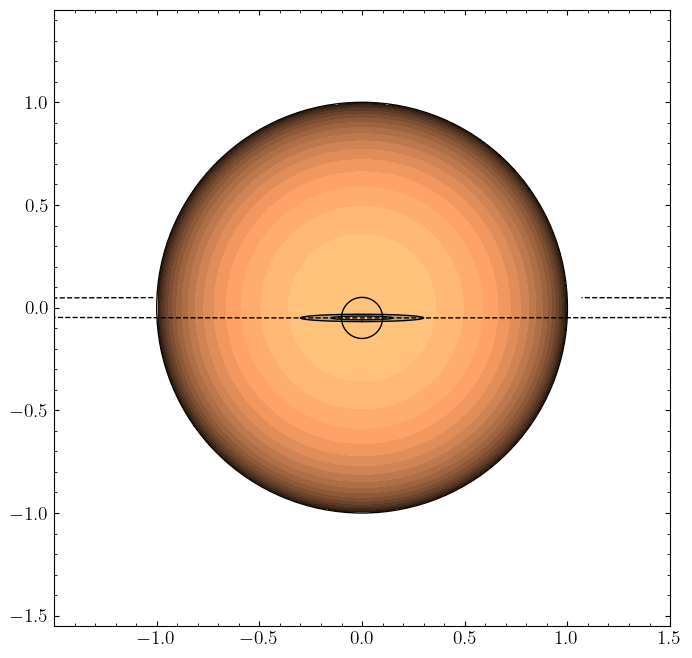

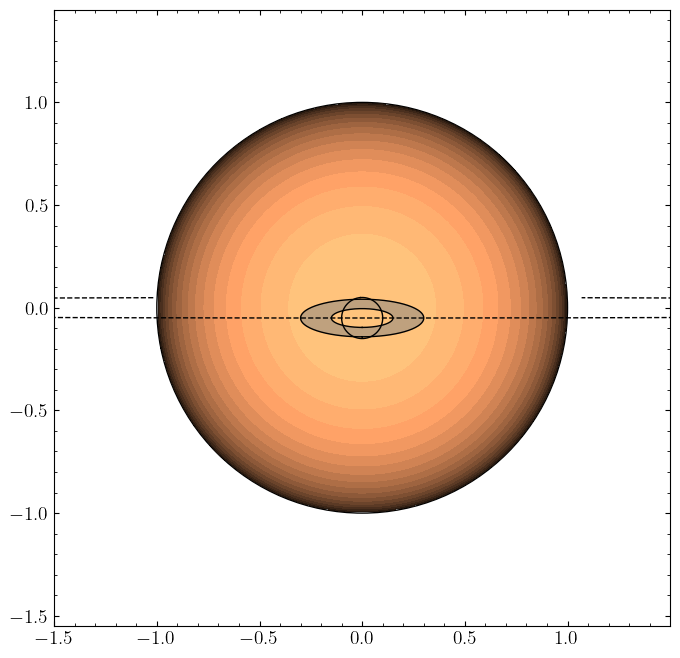

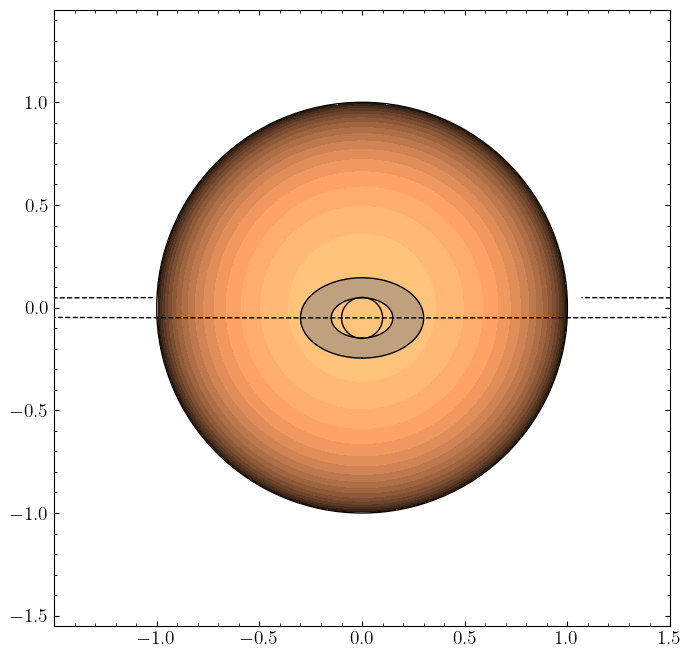

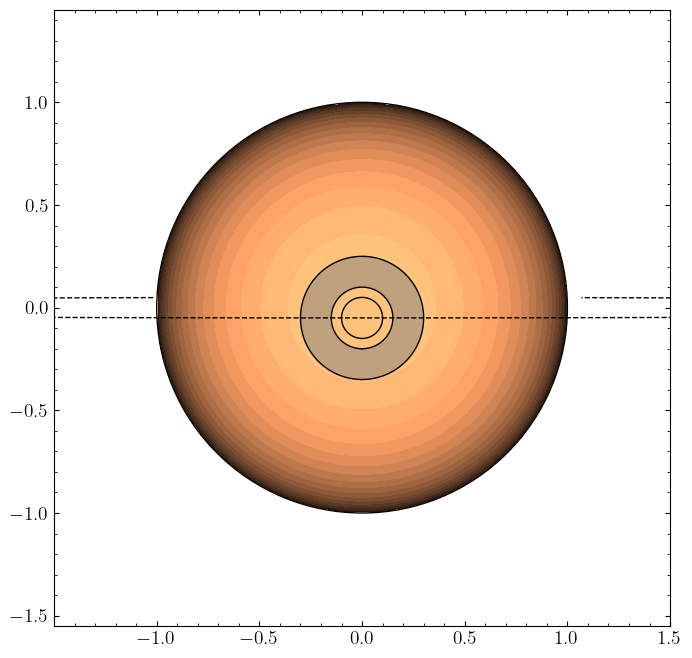

In [24]:
for ring_obliq in [0.05, 0.3, 0.7, jnp.pi / 2]:
    s = state.copy()
    s["obliq"] = ring_obliq
    ringed = RingedSystem(ring_inner_r=0.15, ring_outer_r=0.3, **s)
    ringed.illustrate(window_size=3.0)

At `ring_obliq = 0.05` the annulus is nearly edge-on and adds almost nothing beyond the planet's transit; by `ring_obliq` $= \pi/2$ it is face-on and blocks its full annular area.

### An edge-on ring vanishes exactly

An infinitely thin ring seen perfectly edge-on projects to a line segment and blocks no flux. This limit is handled exactly (with well-defined gradients), rather than through any special-casing or clipping:

In [25]:
edge_on_state = dict(state)
edge_on_state["i"] = jnp.pi / 2

edge_on = RingedSystem(
    ring_inner_r=0.15,
    ring_outer_r=0.3,
    ring_obliq=0.7,
    ring_prec=0.0,
    **edge_on_state,
)
no_ring = OblateSystem(**edge_on_state)

max_diff = jnp.max(jnp.abs(edge_on.lightcurve() - no_ring.lightcurve()))
print(f"max |edge-on ringed - planet only| = {max_diff:.2e}")

max |edge-on ringed - planet only| = 2.22e-16


## Gradients

`RingedSystem` inherits the same gradient machinery as `OblateSystem`: `lightcurve` is wrapped in a `custom_vjp` that computes derivatives with forward-mode differentiation under the hood (much faster than naive reverse mode for this model). Any parameter passed in the call-time dictionary can be differentiated, including all four ring parameters:

In [26]:
def summed_flux(params):
    return jnp.sum(decoupled.lightcurve(params))


grads = jax.grad(summed_flux)(
    {
        "ring_outer_r": jnp.array([0.3]),
        "ring_obliq": jnp.array([0.2]),
    }
)
grads

{'ring_obliq': Array([-11.88697967], dtype=float64),
 'ring_outer_r': Array([-23.11990875], dtype=float64)}

Both gradients are negative, as expected: a larger or more face-on ring blocks more light.

## A note on performance

The ringed model evaluates up to five boundary-integral terms per timestep (plus the intersection tests between the planet, both ring edges, and the stellar limb), so it is substantially more expensive than the planet-only model for in-transit points -- roughly an order of magnitude on a CPU. Out-of-transit points are masked and remain nearly free. See the [performance notebook](https://squishyplanet.readthedocs.io/en/latest/tutorials/performance.html) for measured timings of both the forward models and their gradients.